In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
N_SPLITS = 5
N_PERM   = 200
C        = 1.0
RANDOM_STATE = 0

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)  <-- should be in (0,1)
areas = np.load(AREAS_PATH, allow_pickle=True)

print("Images:", vit.shape[0])
print("Neurons:", R.shape[1])

# Animate / inanimate label (your heuristic)
top1 = np.argmax(vit, axis=1)
y_true = (top1 <= 397).astype(int)
print("Animate fraction:", y_true.mean())



# ------------------------------------------------------------
# STANDARDIZE NEURAL DATA
# ------------------------------------------------------------
scaler = StandardScaler(with_mean=True, with_std=True)
Rz = scaler.fit_transform(R)

# ------------------------------------------------------------
# FUNCTION: compute held-out geometric margins
# ------------------------------------------------------------
def cv_geometric_margins(X, y):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    margins = []

    for train, test in skf.split(X, y):
        clf = LogisticRegression(penalty='l2', C=C, solver='liblinear')
        clf.fit(X[train], y[train])

        w = clf.coef_[0]
        b = clf.intercept_[0]
        w_norm = np.linalg.norm(w)

        scores = (X[test] @ w + b) / w_norm
        signed = (2*y[test]-1) * scores   # convert {0,1} -> {-1,+1}
        margins.append(signed)

    return np.concatenate(margins)

# ------------------------------------------------------------
# REAL DATA
# ------------------------------------------------------------
real_margins = cv_geometric_margins(Rz, y_true)
T_real = np.mean(real_margins)

print("Real mean geometric margin:", T_real)

# ------------------------------------------------------------
# NULL DISTRIBUTION (label permutations)
# ------------------------------------------------------------
null_stats = []

for b in range(N_PERM):
    y_perm = np.random.permutation(y_true)
    m = cv_geometric_margins(Rz, y_perm)
    null_stats.append(np.mean(m))

null_stats = np.array(null_stats)

p_value = (1 + np.sum(null_stats >= T_real)) / (1 + N_PERM)
print("Permutation p-value:", p_value)


Images: 118
Neurons: 39209
Animate fraction: 0.5338983050847458
Real mean geometric margin: 3.0534556427794772
Permutation p-value: 0.004975124378109453


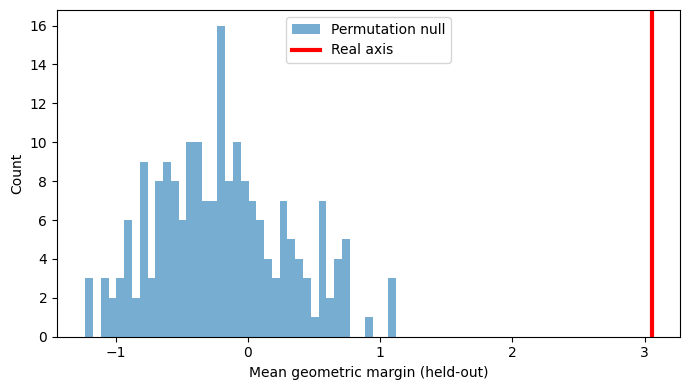

In [3]:
plt.figure(figsize=(7,4))
plt.hist(null_stats, bins=40, alpha=0.6, label="Permutation null")
plt.axvline(T_real, color='red', lw=3, label="Real axis")
plt.xlabel("Mean geometric margin (held-out)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

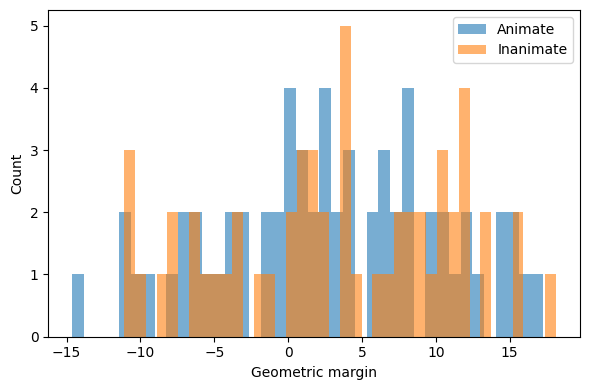

In [4]:
plt.figure(figsize=(6,4))
plt.hist(real_margins[y_true==1], bins=40, alpha=0.6, label="Animate")
plt.hist(real_margins[y_true==0], bins=40, alpha=0.6, label="Inanimate")
plt.xlabel("Geometric margin")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()
